In [1]:
# Author: Rémi Flamary <remi.flamary@polytechnique.edu>
#
# License: MIT License

# sphinx_gallery_thumbnail_number = 3

from sklearn.manifold import MDS
import numpy as np
import matplotlib.pylab as pl
import torch

import ot
from ot.gromov import gromov_wasserstein2

### Graph generation

/home/ansible/miniconda3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/ansible/miniconda3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/ansible/miniconda3/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/tmp/ipykernel_1751605/3306036647.py:39: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmax' will be ignored
  pl.scatter(


(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

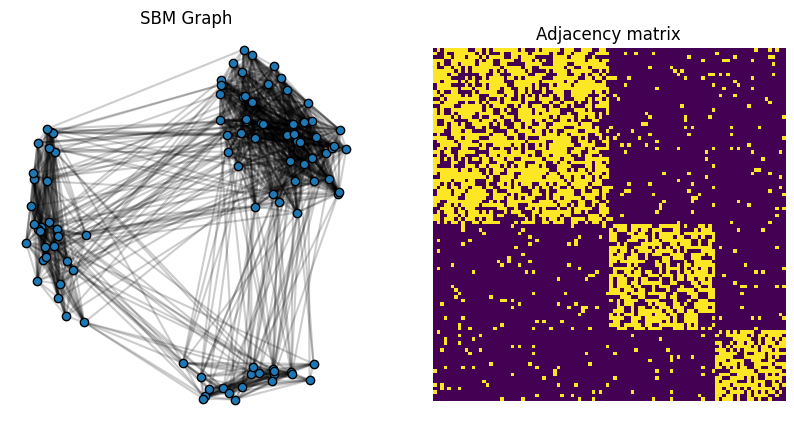

In [2]:
rng = np.random.RandomState(42)


def get_sbm(n, nc, ratio, P):
    nbpc = np.round(n * ratio).astype(int)
    n = np.sum(nbpc)
    C = np.zeros((n, n))
    for c1 in range(nc):
        for c2 in range(c1 + 1):
            if c1 == c2:
                for i in range(np.sum(nbpc[:c1]), np.sum(nbpc[: c1 + 1])):
                    for j in range(np.sum(nbpc[:c2]), i):
                        if rng.rand() <= P[c1, c2]:
                            C[i, j] = 1
            else:
                for i in range(np.sum(nbpc[:c1]), np.sum(nbpc[: c1 + 1])):
                    for j in range(np.sum(nbpc[:c2]), np.sum(nbpc[: c2 + 1])):
                        if rng.rand() <= P[c1, c2]:
                            C[i, j] = 1

    return C + C.T


n = 100
nc = 3
ratio = np.array([0.5, 0.3, 0.2])
P = np.array(0.6 * np.eye(3) + 0.05 * np.ones((3, 3)))
C1 = get_sbm(n, nc, ratio, P)

# get 2d position for nodes
x1 = MDS(dissimilarity="precomputed", random_state=0).fit_transform(1 - C1)


def plot_graph(x, C, color="C0", s=None):
    for j in range(C.shape[0]):
        for i in range(j):
            if C[i, j] > 0:
                pl.plot([x[i, 0], x[j, 0]], [x[i, 1], x[j, 1]], alpha=0.2, color="k")
    pl.scatter(
        x[:, 0], x[:, 1], c=color, s=s, zorder=10, edgecolors="k", cmap="tab10", vmax=9
    )


pl.figure(1, (10, 5))
pl.clf()
pl.subplot(1, 2, 1)
plot_graph(x1, C1, color="C0")
pl.title("SBM Graph")
pl.axis("off")
pl.subplot(1, 2, 2)
pl.imshow(C1, interpolation="nearest")
pl.title("Adjacency matrix")
pl.axis("off")

### Optimizing GW w.r.t the weights on a template structure

Estimated weights :  [0.2998169  0.19984562 0.50033748]
True proportions :  [0.5 0.3 0.2]


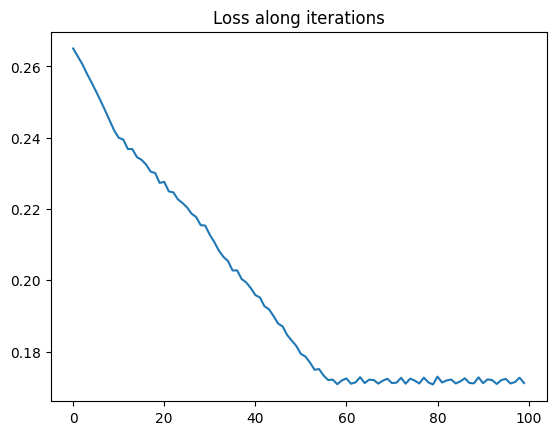

In [3]:
C0 = np.eye(3)


def min_weight_gw(C1, C2, a2, nb_iter_max=100, lr=1e-2):
    """solve min_a GW(C1,C2,a, a2) by gradient descent"""

    # use pyTorch for our data
    C1_torch = torch.tensor(C1)
    C2_torch = torch.tensor(C2)

    a0 = rng.rand(C1.shape[0])  # random_init
    a0 /= a0.sum()  # on simplex
    a1_torch = torch.tensor(a0).requires_grad_(True)
    a2_torch = torch.tensor(a2)

    loss_iter = []

    for i in range(nb_iter_max):
        loss = gromov_wasserstein2(C1_torch, C2_torch, a1_torch, a2_torch)

        loss_iter.append(loss.clone().detach().cpu().numpy())
        loss.backward()

        # print("{:03d} | {}".format(i, loss_iter[-1]))

        # performs a step of projected gradient descent
        with torch.no_grad():
            grad = a1_torch.grad
            a1_torch -= grad * lr  # step
            a1_torch.grad.zero_()
            a1_torch.data = ot.utils.proj_simplex(a1_torch)

    a1 = a1_torch.clone().detach().cpu().numpy()

    return a1, loss_iter


a0_est, loss_iter0 = min_weight_gw(C0, C1, ot.unif(n), nb_iter_max=100, lr=1e-2)

pl.figure(2)
pl.plot(loss_iter0)
pl.title("Loss along iterations")

print("Estimated weights : ", a0_est)
print("True proportions : ", ratio)

### Community clustering with uniform and estimated weights

(np.float64(-0.7232359468853795),
 np.float64(0.5890820430362781),
 np.float64(-0.7698291830273734),
 np.float64(0.6504588509575427))

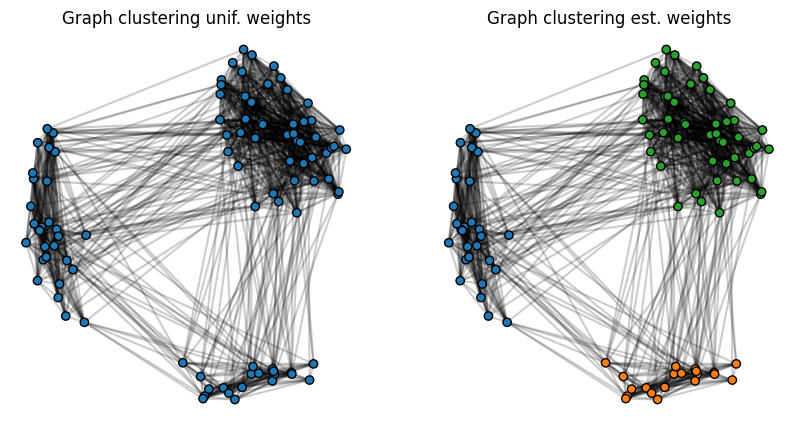

In [4]:
T_unif = ot.gromov_wasserstein(C1, C0, ot.unif(n), ot.unif(3))
label_unif = T_unif.argmax(1)

T_est = ot.gromov_wasserstein(C1, C0, ot.unif(n), a0_est)
label_est = T_est.argmax(1)

pl.figure(3, (10, 5))
pl.clf()
pl.subplot(1, 2, 1)
plot_graph(x1, C1, color=label_unif)
pl.title("Graph clustering unif. weights")
pl.axis("off")
pl.subplot(1, 2, 2)
plot_graph(x1, C1, color=label_est)
pl.title("Graph clustering est. weights")
pl.axis("off")

### Graph compression with GW

Estimated weights :  [0.29161705 0.19356687 0.51481608]
True proportions :  [0.5 0.3 0.2]


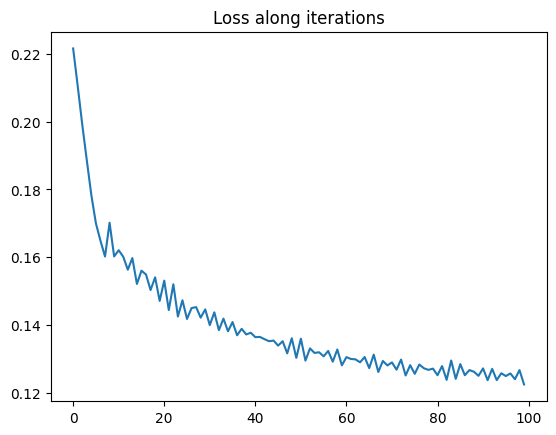

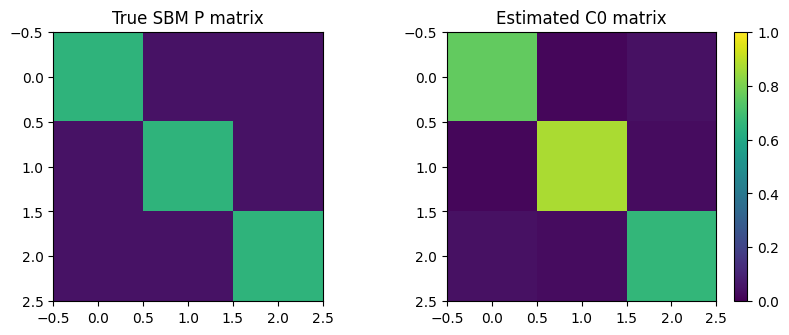

In [5]:
def graph_compression_gw(nb_nodes, C2, a2, nb_iter_max=100, lr=1e-2):
    """solve min_a GW(C1,C2,a, a2) by gradient descent"""

    # use pyTorch for our data

    C2_torch = torch.tensor(C2)
    a2_torch = torch.tensor(a2)

    a0 = rng.rand(nb_nodes)  # random_init
    a0 /= a0.sum()  # on simplex
    a1_torch = torch.tensor(a0).requires_grad_(True)
    C0 = np.eye(nb_nodes)
    C1_torch = torch.tensor(C0).requires_grad_(True)

    loss_iter = []

    for i in range(nb_iter_max):
        loss = gromov_wasserstein2(C1_torch, C2_torch, a1_torch, a2_torch)

        loss_iter.append(loss.clone().detach().cpu().numpy())
        loss.backward()

        # print("{:03d} | {}".format(i, loss_iter[-1]))

        # performs a step of projected gradient descent
        with torch.no_grad():
            grad = a1_torch.grad
            a1_torch -= grad * lr  # step
            a1_torch.grad.zero_()
            a1_torch.data = ot.utils.proj_simplex(a1_torch)

            grad = C1_torch.grad
            C1_torch -= grad * lr  # step
            C1_torch.grad.zero_()
            C1_torch.data = torch.clamp(C1_torch, 0, 1)

    a1 = a1_torch.clone().detach().cpu().numpy()
    C1 = C1_torch.clone().detach().cpu().numpy()

    return a1, C1, loss_iter


nb_nodes = 3
a0_est2, C0_est2, loss_iter2 = graph_compression_gw(
    nb_nodes, C1, ot.unif(n), nb_iter_max=100, lr=5e-2
)

pl.figure(4)
pl.plot(loss_iter2)
pl.title("Loss along iterations")


print("Estimated weights : ", a0_est2)
print("True proportions : ", ratio)

pl.figure(6, (10, 3.5))
pl.clf()
pl.subplot(1, 2, 1)
pl.imshow(P, vmin=0, vmax=1)
pl.title("True SBM P matrix")
pl.subplot(1, 2, 2)
pl.imshow(C0_est2, vmin=0, vmax=1)
pl.title("Estimated C0 matrix")
pl.colorbar()